# Simulación Ideal del Algoritmo de Shor para $N = 15$

## Notebook Didáctico: De la Teoría Matemática a la Implementación en Qiskit

> **Referencia principal:** Nielsen & Chuang, *Quantum Computation and Quantum Information*, Capítulo 5.
>
> **Objetivo:** Construir paso a paso el circuito cuántico del algoritmo de Shor, demostrando rigurosamente la física y las matemáticas de cada bloque, y verificando su corrección mediante simulación ideal.

### Estructura del Notebook

1. **Transformada Cuántica de Fourier (QFT)** — §5.1
2. **Estimación de Fase Cuántica (QPE)** — §5.2
3. **Exponenciación Modular y el Operador $U_a$** — §5.3.1
4. **Circuito Completo de Shor (RegisterQC)** — Ensamblaje y ejecución
5. **Post-procesamiento Clásico: Fracciones Continuas** — §5.3.1, Teorema 5.1
6. **Análisis de Fidelidad** — Verificación cuantitativa


In [1]:
# ─── CONFIGURACIÓN E IMPORTACIONES ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, ceil, log2
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

# Parámetros globales
N = 15                          # Número a factorizar
CONTROL_QUBITS = 9              # t = 2*ceil(log2(N)) + 1
TARGET_QUBITS = ceil(log2(N))   # L = ceil(log2(15)) = 4
SHOTS = 4096
SEED = 457

print(f"N = {N}")
print(f"Qubits de control: t = {CONTROL_QUBITS}")
print(f"Qubits target: L = {TARGET_QUBITS}")
print(f"Total qubits: {CONTROL_QUBITS + TARGET_QUBITS}")


N = 15
Qubits de control: t = 9
Qubits target: L = 4
Total qubits: 13


---
# 1. Transformada Cuántica de Fourier (QFT)

## 1.1 Definición Formal (N&C Ec. 5.2, pág. 217)

La QFT sobre una base ortonormal $|0\rangle, |1\rangle, \ldots, |2^n - 1\rangle$ se define como:

$$|j\rangle \xrightarrow{\text{QFT}} \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i jk / 2^n} |k\rangle \tag{Ec. 5.2}$$

## 1.2 Representación de Producto Tensorial (N&C Ec. 5.4, pág. 218)

Usando la notación de **fracción binaria**: $0.j_l j_{l+1}\cdots j_m \equiv j_l/2 + j_{l+1}/4 + \cdots + j_m / 2^{m-l+1}$,

la QFT admite una forma factorizada:

$$|j_1 j_2 \cdots j_n\rangle \xrightarrow{\text{QFT}} \frac{\bigl(|0\rangle + e^{2\pi i\, 0.j_n}|1\rangle\bigr) \otimes \bigl(|0\rangle + e^{2\pi i\, 0.j_{n-1}j_n}|1\rangle\bigr) \otimes \cdots \otimes \bigl(|0\rangle + e^{2\pi i\, 0.j_1 j_2\cdots j_n}|1\rangle\bigr)}{2^{n/2}} \tag{Ec. 5.4}$$

**Observación crucial:** El primer factor del producto tensorial depende **solo** de $j_n$ (bit menos significativo), y el último depende de **todos** los bits. Esto determina la estructura del circuito.

### Demostración de la Ec. 5.4

Partimos de la Ec. 5.2 y escribimos $k$ en binario: $k = k_1 2^{n-1} + k_2 2^{n-2} + \cdots + k_n 2^0$:

$$\text{QFT}|j\rangle = \frac{1}{2^{n/2}} \sum_{k=0}^{2^n-1} e^{2\pi i j k / 2^n} |k\rangle = \frac{1}{2^{n/2}} \sum_{k_1=0}^{1}\cdots\sum_{k_n=0}^{1} e^{2\pi i j \sum_{l=1}^{n} k_l 2^{-l}} |k_1\cdots k_n\rangle$$

La exponencial se factoriza como producto:

$$= \frac{1}{2^{n/2}} \bigotimes_{l=1}^{n} \left[\sum_{k_l=0}^{1} e^{2\pi i j k_l 2^{-l}} |k_l\rangle\right] = \frac{1}{2^{n/2}} \bigotimes_{l=1}^{n} \bigl(|0\rangle + e^{2\pi i j / 2^l} |1\rangle\bigr)$$

Finalmente, $e^{2\pi i j/2^l} = e^{2\pi i\, 0.j_{n-l+1}\cdots j_n}$ (los bits enteros de $j/2^l$ contribuyen múltiplos de $2\pi$ que desaparecen). $\blacksquare$

## 1.3 Compuertas del Circuito (N&C Ec. 5.11, pág. 219)

La compuerta de rotación de fase:

$$R_k \equiv \begin{bmatrix} 1 & 0 \\ 0 & e^{2\pi i / 2^k} \end{bmatrix} \tag{Ec. 5.11}$$

El circuito de la QFT aplica a cada qubit $l$:
1. Una compuerta **Hadamard** $H$
2. Rotaciones controladas $CR_2, CR_3, \ldots, CR_{n-l+1}$ desde los qubits posteriores

**Total de compuertas:** $n(n+1)/2$ (complejidad $\Theta(n^2)$), más $\lfloor n/2 \rfloor$ SWAPs para invertir el orden de salida.


## 1.4 Mapeo Teórico → Qiskit

| Ecuación Matemática | Implementación Qiskit |
|:---|:---|
| $H\|j_l\rangle = \frac{1}{\sqrt{2}}(\|0\rangle + e^{2\pi i\, 0.j_l}\|1\rangle)$ | `qc.h(qubit_l)` |
| $CR_k$: rotación $e^{2\pi i / 2^k}$ controlada | `qc.cp(2*np.pi / 2**k, control, target)` |
| SWAP para reordenar la salida | `qc.swap(i, n-1-i)` |

En Qiskit, la clase `QFT(n)` implementa exactamente este circuito. A continuación lo construimos manualmente para verificar.


In [2]:
# ─── CONSTRUCCIÓN MANUAL DE LA QFT ─────────────────────────────────────
# En Qiskit, qubit 0 = LSB. La QFT de N&C (Figura 5.1) procesa desde el MSB.
# En Qiskit, el MSB es el qubit de índice más alto (n-1).
# Por tanto iteramos desde n-1 hacia 0 para coincidir con la convención de Qiskit.

n = 4  # Ejemplo con 4 qubits para visualización clara

qft_manual = QuantumCircuit(n, name='QFT_manual')

for target_qubit in range(n - 1, -1, -1):  # MSB primero: n-1, n-2, ..., 0
    # Paso 1: Hadamard en el qubit actual
    # H|j_l⟩ = (|0⟩ + e^{2πi · 0.j_l} |1⟩) / √2
    qft_manual.h(target_qubit)
    
    # Paso 2: Rotaciones controladas CR_k desde qubits anteriores (índice menor)
    # Cada CR_k añade la fase e^{2πi / 2^k} condicionada al qubit de control
    for k, control_qubit in enumerate(range(target_qubit - 1, -1, -1)):
        angle = 2 * np.pi / (2 ** (k + 2))  # R_{k+2} porque k empieza en 0
        qft_manual.cp(angle, control_qubit, target_qubit)

# Paso 3: SWAPs para invertir el orden de los qubits de salida
# (La Ec. 5.4 produce los qubits en orden inverso al de Qiskit)
for i in range(n // 2):
    qft_manual.swap(i, n - 1 - i)

print("Circuito QFT manual (4 qubits):")
qft_manual.draw(output='text', fold=120)


Circuito QFT manual (4 qubits):


┌───┐   
q_0: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├─X─
                                  │                 │       ┌───┐ │P(π/2) └───┘ │ 
q_1: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X───┼─
                    │       ┌───┐ │        │P(π/2)  │P(π/4) └───┘           │   │ 
q_2: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X───┼─
     ┌───┐ │P(π/2)  │P(π/4) └───┘ │P(π/8)                                       │ 
q_3: ┤ H ├─■────────■─────────────■─────────────────────────────────────────────X─
     └───┘

In [3]:
# ─── COMPARACIÓN: QFT MANUAL vs QFTGate DE QISKIT ─────────────────────
# Usamos QFTGate (recomendado en Qiskit 2.x) en lugar del QFT deprecado
qft_gate = QFTGate(n)

# Verificar que ambas son equivalentes (misma matriz unitaria)
U_manual = Operator(qft_manual)
U_qiskit = Operator(qft_gate)

norma_diferencia = np.linalg.norm(U_manual.data - U_qiskit.data, 'fro')
print(f"||QFT_manual - QFTGate||_F = {norma_diferencia:.2e}")
print(f"¿Son equivalentes? {'✅ Sí' if norma_diferencia < 1e-10 else '❌ No'}")

# Verificar unitariedad: U†U = I
UdagU = U_manual.data.conj().T @ U_manual.data
norma_unitariedad = np.linalg.norm(UdagU - np.eye(2**n), 'fro')
print(f"||U†U - I||_F = {norma_unitariedad:.2e} → {'✅ Unitario' if norma_unitariedad < 1e-10 else '❌'}")

# Verificar QFT · QFT⁻¹ = I
U_inv = Operator(QFTGate(n).inverse())
producto = U_manual.compose(U_inv)
norma_inversa = np.linalg.norm(producto.data - np.eye(2**n), 'fro')
print(f"||QFT · QFT⁻¹ - I||_F = {norma_inversa:.2e} → {'✅' if norma_inversa < 1e-10 else '❌'}")


||QFT_manual - QFTGate||_F = 7.79e-15
¿Son equivalentes? ✅ Sí
||U†U - I||_F = 2.33e-15 → ✅ Unitario
||QFT · QFT⁻¹ - I||_F = 2.27e-15 → ✅


---
# 2. Exponenciación Modular: El Operador $U_a$

## 2.1 Definición (N&C Ec. 5.36, pág. 227)

Para el order-finding, definimos el operador unitario:

$$U_a |y\rangle \equiv |ay \bmod N\rangle \tag{Ec. 5.36}$$

Para $N = 15$, el registro target tiene $L = \lceil\log_2 15\rceil = 4$ qubits, y $U_a$ es una **matriz de permutación** de dimensión $16 \times 16$.

### Construcción explícita de la matriz

Para cada estado base $|y\rangle$ con $0 \le y < N$:
- $U_a$ envía $|y\rangle \mapsto |ay \bmod N\rangle$

Para $y \ge N$: $U_a|y\rangle = |y\rangle$ (identidad).

**Ejemplo:** Para $a = 7$, $N = 15$:

| $y$ | $7y \bmod 15$ | | $y$ | $7y \bmod 15$ |
|:---:|:---:|-|:---:|:---:|
| 0 | 0 | | 8 | 11 |
| 1 | 7 | | 9 | 3 |
| 2 | 14 | | 10 | 10 |
| 3 | 6 | | 11 | 2 |
| 4 | 13 | | 12 | 9 |
| 5 | 5 | | 13 | 1 |
| 6 | 12 | | 14 | 8 |
| 7 | 4 | | 15 | 15 |

## 2.2 Eigenestados y Eigenvalores (N&C Ec. 5.37–5.39, pág. 227)

Los eigenestados de $U_a$ son:

$$|u_s\rangle \equiv \frac{1}{\sqrt{r}} \sum_{k=0}^{r-1} \exp\!\left(\frac{-2\pi i s k}{r}\right) |a^k \bmod N\rangle, \quad s = 0, 1, \ldots, r-1 \tag{Ec. 5.37}$$

**Demostración de que son eigenestados:**

$$U_a |u_s\rangle = \frac{1}{\sqrt{r}} \sum_{k=0}^{r-1} e^{-2\pi i sk/r}\, |a^{k+1} \bmod N\rangle$$

Sustituyendo $k' = k+1$ y usando $a^r \equiv 1 \pmod{N}$ (periodicidad):

$$= e^{2\pi i s/r} \cdot \frac{1}{\sqrt{r}} \sum_{k'=0}^{r-1} e^{-2\pi i sk'/r}\, |a^{k'} \bmod N\rangle = e^{2\pi i s/r}\, |u_s\rangle$$

$$\boxed{U_a |u_s\rangle = e^{2\pi i s/r}\, |u_s\rangle} \tag{Ec. 5.39}$$

## 2.3 Identidad Fundamental (N&C Ec. 5.45, pág. 228)

$$|1\rangle = \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1} |u_s\rangle \tag{Ec. 5.45}$$

Esta identidad es **clave**: al preparar el registro target en $|1\rangle$, el QPE mide aleatoriamente una fase $s/r$ con probabilidad $1/r$.

## 2.4 Periodicidad

$$(U_a)^r = I, \quad \text{donde } r = \text{ord}_N(a)$$

Esto se verifica directamente: aplicar $a \cdot (\cdot) \bmod N$ un total de $r$ veces devuelve al estado original.


In [4]:
# ─── CONSTRUCCIÓN EXPLÍCITA DE U_a COMO MATRIZ DE PERMUTACIÓN ─────────
def construir_U_a(a, N):
    """
    Construye la matriz unitaria U_a |y⟩ = |ay mod N⟩.
    Para y >= N, U_a actúa como identidad.
    """
    L = ceil(log2(N))
    dim = 2 ** L
    U = np.eye(dim, dtype=complex)
    
    for y in range(N):
        target = (a * y) % N
        # Poner un 1 en la posición (target, y) y un 0 en (y, y)
        U[y, y] = 0
        U[target, y] = 1
    
    return U

# Construir para a = 7, N = 15
a_ejemplo = 7
U_7 = construir_U_a(a_ejemplo, N)

print(f"Matriz U_{{a={a_ejemplo}}} (dimensión {U_7.shape[0]}×{U_7.shape[1]}):")
print(f"¿Es unitaria? ||U†U - I|| = {np.linalg.norm(U_7.conj().T @ U_7 - np.eye(16), 'fro'):.2e}")

# Verificar periodicidad: (U_a)^r = I
r_7 = 4  # ord_15(7) = 4
U_7_r = np.linalg.matrix_power(U_7, r_7)
print(f"¿(U_7)^{r_7} = I? ||U^r - I|| = {np.linalg.norm(U_7_r - np.eye(16), 'fro'):.2e}")

# Mostrar la permutación
print(f"\nPermutación de U_{{a=7}} (y → 7y mod 15):")
for y in range(N):
    print(f"  |{y}⟩ → |{(a_ejemplo * y) % N}⟩", end="  ")
    if y % 4 == 3: print()


Matriz U_{a=7} (dimensión 16×16):
¿Es unitaria? ||U†U - I|| = 0.00e+00
¿(U_7)^4 = I? ||U^r - I|| = 0.00e+00

Permutación de U_{a=7} (y → 7y mod 15):
  |0⟩ → |0⟩    |1⟩ → |7⟩    |2⟩ → |14⟩    |3⟩ → |6⟩  
  |4⟩ → |13⟩    |5⟩ → |5⟩    |6⟩ → |12⟩    |7⟩ → |4⟩  
  |8⟩ → |11⟩    |9⟩ → |3⟩    |10⟩ → |10⟩    |11⟩ → |2⟩  
  |12⟩ → |9⟩    |13⟩ → |1⟩    |14⟩ → |8⟩  

In [5]:
# ─── VERIFICAR EIGENVALORES ────────────────────────────────────────────
eigenvalores, eigenvectores = np.linalg.eig(U_7)

print(f"Eigenvalores de U_{{a=7}} (r=4, fases esperadas: 0, 1/4, 1/2, 3/4):\n")
fases = np.angle(eigenvalores) / (2 * np.pi)
fases_positivas = np.mod(fases, 1)  # Llevar a [0, 1)
fases_unicas = sorted(set(np.round(fases_positivas, 6)))

for phi in fases_unicas:
    multiplicidad = sum(1 for p in np.round(fases_positivas, 6) if p == phi)
    print(f"  φ = {phi:.4f} (= {Fraction(phi).limit_denominator(20)}), multiplicidad = {multiplicidad}")


Eigenvalores de U_{a=7} (r=4, fases esperadas: 0, 1/4, 1/2, 3/4):

  φ = 0.0000 (= 0), multiplicidad = 7
  φ = 0.2500 (= 1/4), multiplicidad = 3
  φ = 0.5000 (= 1/2), multiplicidad = 3
  φ = 0.7500 (= 3/4), multiplicidad = 3


In [6]:
# ─── CONSTRUIR CIRCUITO CONTROLADO C-U_b COMO EN RegisterQC ───────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('.'))))
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

# Función b_mod_n del RegisterQC (matriz de permutación)
def b_mod_n(b, N):
    """Construye la compuerta unitaria U_b |y⟩ = |by mod N⟩."""
    L = ceil(log2(N))
    dim = 2 ** L
    U = np.eye(dim, dtype=complex)
    for y in range(N):
        U[y, y] = 0
        U[(b * y) % N, y] = 1
    return UnitaryGate(U, label=f"U_{b}")

# Ejemplo: construir C-U_7 (controlado por 1 qubit)
gate_U7 = b_mod_n(7, 15)
qc_ctrl = QuantumCircuit(TARGET_QUBITS + 1)
qc_ctrl.compose(gate_U7.control(), qubits=list(range(TARGET_QUBITS + 1)), inplace=True)

print("Circuito C-U_7 (1 qubit control + 4 qubits target):")
print(qc_ctrl.draw(output='text'))


Circuito C-U_7 (1 qubit control + 4 qubits target):
             
q_0: ───■────
     ┌──┴───┐
q_1: ┤0     ├
     │      │
q_2: ┤1     ├
     │  U_7 │
q_3: ┤2     ├
     │      │
q_4: ┤3     ├
     └──────┘


---
# 3. Estimación de Fase Cuántica (QPE) y Circuito Completo

## 3.1 El Circuito QPE (N&C §5.2, pág. 222)

El QPE estima la fase $\varphi$ de un eigenvalor $e^{2\pi i \varphi}$ de un operador unitario $U$.

### Evolución del estado paso a paso

**Estado inicial:** $|\psi_0\rangle = |0\rangle^{\otimes t} |1\rangle$ ($t$ qubits de control + target en $|1\rangle$)

**Paso 1 — Hadamard en todos los qubits de control:**

$$|\psi_1\rangle = \frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t-1} |k\rangle \otimes |1\rangle$$

**Paso 2 — Aplicación de las $C$-$U_{a^{2^j}}$ controladas:**

El qubit de control $j$ (contando desde $j=0$) controla la aplicación de $U_a^{2^j}$. Dado que $|1\rangle = \frac{1}{\sqrt{r}}\sum_s |u_s\rangle$ (Ec. 5.45), el estado evoluciona a:

$$|\psi_2\rangle = \frac{1}{\sqrt{2^t}} \sum_{k=0}^{2^t-1} e^{2\pi i \varphi k} |k\rangle \otimes |u\rangle \tag{Ec. 5.20}$$

donde $\varphi = s/r$ para algún $s$ aleatorio. Los exponentes controlados acumulan la fase $\varphi \cdot k$ en el registro de control.

**Paso 3 — QFT inversa en el registro de control:**

$$|\psi_3\rangle = |\tilde{\varphi}\rangle \otimes |u\rangle$$

donde $|\tilde{\varphi}\rangle$ es la mejor aproximación de $t$ bits a la fase $\varphi = s/r$.

**Paso 4 — Medición del registro de control:**

Se obtiene $y \approx s \cdot 2^t / r$, del cual se extrae $r$ con fracciones continuas.

## 3.2 Circuito RegisterQC para $N = 15$

El circuito implementa:
1. Hadamard en los $t = 9$ qubits de control
2. $t$ operaciones controladas: $C_j$-$U_{a^{2^j} \bmod N}$ para $j = 0, \ldots, t-1$
3. QFT$^{-1}$ en el registro de control
4. Medición

Cuando $a^{2^j} \bmod N = 1$, la compuerta correspondiente es la identidad ($C$-$I$, no hace nada), lo cual simplifica enormemente el circuito para períodos pequeños.


In [7]:
# ─── CONSTRUCCIÓN DEL CIRCUITO COMPLETO DE SHOR ───────────────────────
def construir_circuito_shor(a, N, t, L):
    """
    Construye el circuito completo del algoritmo de Shor (RegisterQC)
    para factorizar N usando la base a.
    
    Parámetros:
        a: base coprime con N
        N: número a factorizar
        t: número de qubits de control
        L: número de qubits target (ceil(log2(N)))
    """
    # Registros
    control = QuantumRegister(t, 'control')
    target = QuantumRegister(L, 'target')
    classical = ClassicalRegister(t, 'output')
    qc = QuantumCircuit(control, target, classical)
    
    # ─── Paso 0: Inicializar target en |1⟩ ────────────
    # |1⟩ = |0001⟩ en 4 qubits (bit menos significativo)
    qc.x(target[0])  # |0000⟩ → |0001⟩ = |1⟩
    qc.barrier()
    
    # ─── Paso 1: Hadamard en todos los qubits de control ────
    # |0⟩^⊗t → (1/√2^t) Σ_k |k⟩
    for j in range(t):
        qc.h(control[j])
    qc.barrier()
    
    # ─── Paso 2: Exponenciaciones modulares controladas ────
    # C_j-U_{a^{2^j} mod N} para j = 0, ..., t-1
    for j in range(t):
        b = pow(a, 2**j, N)  # b = a^{2^j} mod N
        
        if b == 1:
            # U_1 = I (identidad), no hace nada
            continue
        
        # Construir la compuerta unitaria U_b y su versión controlada
        gate = b_mod_n(b, N)
        controlled_gate = gate.control()
        
        # Aplicar: qubit de control j + qubits target
        qubits = [control[j]] + list(target)
        qc.compose(controlled_gate, qubits=qubits, inplace=True)
    
    qc.barrier()
    
    # ─── Paso 3: QFT inversa en el registro de control ────
    qft_inv = QFTGate(t).inverse()
    qc.compose(qft_inv, qubits=control, inplace=True)
    qc.barrier()
    
    # ─── Paso 4: Medición ────
    qc.measure(control, classical)
    
    return qc

# Construir para a = 7 (ejemplo didáctico, r = 4)
a_demo = 7
qc_shor = construir_circuito_shor(a_demo, N, CONTROL_QUBITS, TARGET_QUBITS)

print(f"Circuito de Shor para N={N}, a={a_demo}:")
print(f"  Qubits totales: {qc_shor.num_qubits}")
print(f"  Profundidad: {qc_shor.depth()}")
print(f"  Compuertas: {qc_shor.size()}")
print(qc_shor.draw(output='text', fold=100))


Circuito de Shor para N=15, a=7:
  Qubits totales: 13
  Profundidad: 6
  Compuertas: 22
                 ░ ┌───┐ ░                  ░ ┌─────────┐ ░ ┌─┐                        
control_0: ──────░─┤ H ├─░────■─────────────░─┤0        ├─░─┤M├────────────────────────
                 ░ ├───┤ ░    │             ░ │         │ ░ └╥┘┌─┐                     
control_1: ──────░─┤ H ├─░────┼───────■─────░─┤1        ├─░──╫─┤M├─────────────────────
                 ░ ├───┤ ░    │       │     ░ │         │ ░  ║ └╥┘┌─┐                  
control_2: ──────░─┤ H ├─░────┼───────┼─────░─┤2        ├─░──╫──╫─┤M├──────────────────
                 ░ ├───┤ ░    │       │     ░ │         │ ░  ║  ║ └╥┘┌─┐               
control_3: ──────░─┤ H ├─░────┼───────┼─────░─┤3        ├─░──╫──╫──╫─┤M├───────────────
                 ░ ├───┤ ░    │       │     ░ │         │ ░  ║  ║  ║ └╥┘┌─┐            
control_4: ──────░─┤ H ├─░────┼───────┼─────░─┤4 qft_dg ├─░──╫──╫──╫──╫─┤M├────────────
                 ░ ├───┤ ░    │ 

In [8]:
# ─── EJECUCIÓN DEL CIRCUITO EN SIMULADOR IDEAL ───────────────────────
simulator = AerSimulator()

# Transpilar para el simulador genérico (all-to-all)
qc_transpiled = transpile(qc_shor, backend=simulator, optimization_level=3, seed_transpiler=SEED)

print(f"Circuito transpilado:")
print(f"  Profundidad total: {qc_transpiled.depth()}")
print(f"  Profundidad 2Q: {qc_transpiled.depth(lambda i: i.operation.num_qubits == 2)}")
print(f"  Compuertas totales: {qc_transpiled.size()}")

# Ejecutar
sampler = SamplerV2(mode=simulator)
job = sampler.run([(qc_transpiled,)], shots=SHOTS)
result = job.result()[0]
counts = result.data.output.get_counts()

# Mostrar los resultados más frecuentes
print(f"\nResultados de medición (top 10 de {SHOTS} shots):")
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
for bs, count in sorted_counts[:10]:
    y = int(bs, 2)
    phase = y / (2**CONTROL_QUBITS)
    prob = count / SHOTS
    print(f"  |{bs}⟩ (y={y:>3d})  →  fase ≈ {phase:.6f}  →  prob = {prob:.4f} ({count}/{SHOTS})")


Circuito transpilado:
  Profundidad total: 934
  Profundidad 2Q: 476
  Compuertas totales: 1301



Resultados de medición (top 10 de 4096 shots):
  |000000000⟩ (y=  0)  →  fase ≈ 0.000000  →  prob = 0.2563 (1050/4096)
  |100000000⟩ (y=256)  →  fase ≈ 0.500000  →  prob = 0.2549 (1044/4096)
  |010000000⟩ (y=128)  →  fase ≈ 0.250000  →  prob = 0.2461 (1008/4096)
  |110000000⟩ (y=384)  →  fase ≈ 0.750000  →  prob = 0.2427 (994/4096)


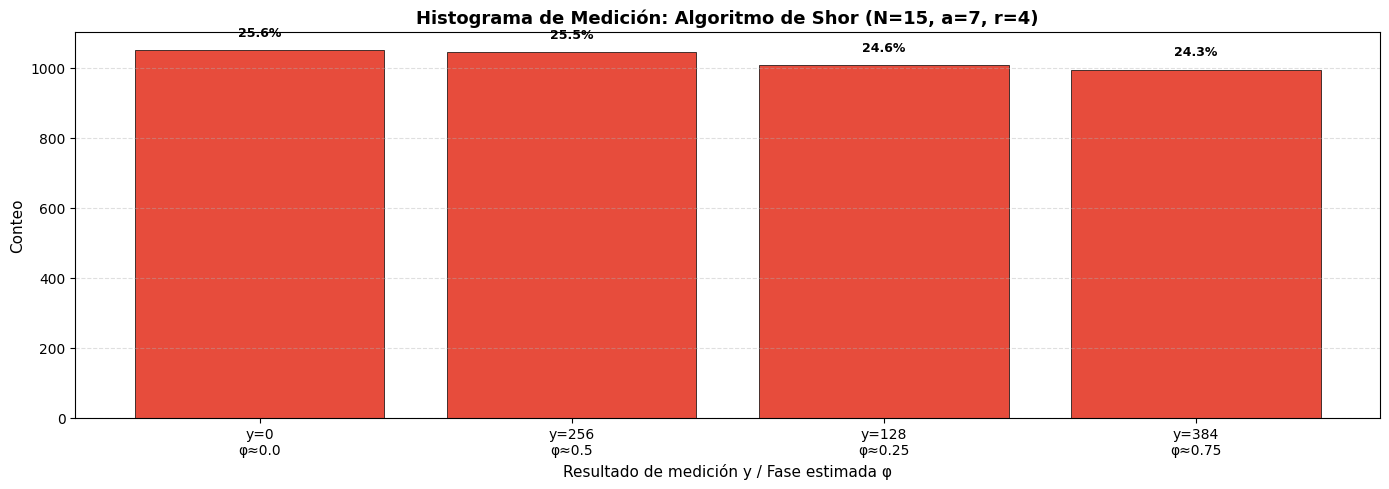

In [9]:
# ─── HISTOGRAMA DE RESULTADOS ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Convertir bitstrings a fases
phases = {}
for bs, count in counts.items():
    y = int(bs, 2)
    phase = round(y / (2**CONTROL_QUBITS), 6)
    phases[f"y={y}\nφ≈{phase}"] = count

# Ordenar por conteo descendente y tomar top
sorted_phases = dict(sorted(phases.items(), key=lambda x: x[1], reverse=True)[:8])

colors = ['#e74c3c' if v > SHOTS/10 else '#95a5a6' for v in sorted_phases.values()]
bars = ax.bar(sorted_phases.keys(), sorted_phases.values(), color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, sorted_phases.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + SHOTS*0.01,
            f"{val/SHOTS*100:.1f}%", ha='center', fontsize=9, fontweight='bold')

ax.set_title(f"Histograma de Medición: Algoritmo de Shor (N={N}, a={a_demo}, r=4)", fontsize=13, fontweight='bold')
ax.set_xlabel("Resultado de medición y / Fase estimada φ", fontsize=11)
ax.set_ylabel("Conteo", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


---
# 4. Post-procesamiento Clásico: De la Fase a los Factores

## 4.1 El problema

La medición cuántica nos da un entero $y \in \{0, 1, \ldots, 2^t - 1\}$. La fase estimada es:

$$\tilde{\varphi} = \frac{y}{2^t} \approx \frac{s}{r}$$

Conocemos $\tilde{\varphi}$ como número decimal, pero necesitamos recuperar el **denominador** $r$ de la fracción irreducible $s/r$.

## 4.2 Algoritmo de Fracciones Continuas (N&C Teorema 5.1, pág. 229)

> **Teorema 5.1.** Si $\left|\frac{s}{r} - \varphi\right| \le \frac{1}{2r^2}$, entonces $s/r$ es un **convergente** de la fracción continua de $\varphi$.

### Recursión de Euler para convergentes (N&C Box 5.3, pág. 230)

$$p_k = a_k \cdot p_{k-1} + p_{k-2}, \quad q_k = a_k \cdot q_{k-1} + q_{k-2}$$

con semillas: $p_{-2} = 0,\; p_{-1} = 1,\; q_{-2} = 1,\; q_{-1} = 0$

## 4.3 Extracción de factores (N&C §5.3.2, pág. 233)

Una vez encontrado el período $r$ (par):

$$a^r \equiv 1 \pmod{N} \implies (a^{r/2} - 1)(a^{r/2} + 1) \equiv 0 \pmod{N}$$

Si $a^{r/2} \not\equiv \pm 1 \pmod{N}$, entonces:

$$p = \gcd(a^{r/2} - 1, N), \quad q = \gcd(a^{r/2} + 1, N)$$

son **factores no triviales** de $N$.


In [10]:
# ─── IMPLEMENTACIÓN DEL ALGORITMO DE FRACCIONES CONTINUAS ─────────────
def descomponer_fc(numerador, denominador):
    """Descompone numerador/denominador en coeficientes [a0; a1, a2, ...]."""
    coefs = []
    while denominador != 0:
        a = numerador // denominador
        coefs.append(a)
        numerador, denominador = denominador, numerador - a * denominador
    return coefs

def calcular_convergentes(coefs):
    """Calcula convergentes p_k/q_k con recursión de Euler."""
    convergentes = []
    p2, q2 = 0, 1   # p_{-2}, q_{-2}
    p1, q1 = 1, 0   # p_{-1}, q_{-1}
    for a_k in coefs:
        pk = a_k * p1 + p2
        qk = a_k * q1 + q2
        convergentes.append((pk, qk))
        p2, p1 = p1, pk
        q2, q1 = q1, qk
    return convergentes

def extraer_factores(y, t, a, N):
    """Cadena completa: medición y → fase → FC → período → factores."""
    dim = 2 ** t
    phase = y / dim
    
    if y == 0:
        return {"y": y, "phase": 0, "r": None, "factors": None, "note": "y=0 no aporta información"}
    
    coefs = descomponer_fc(y, dim)
    convs = calcular_convergentes(coefs)
    
    # Buscar el denominador q_k que sea período válido
    for pk, qk in convs:
        if 1 < qk < N and pow(a, qk, N) == 1:
            r = qk
            if r % 2 == 0:
                g1 = gcd(pow(a, r // 2) - 1, N)
                g2 = gcd(pow(a, r // 2) + 1, N)
                factors = sorted([g1, g2]) if (1 < g1 < N and 1 < g2 < N) else None
                trivial = g1 in (1, N) or g2 in (1, N)
                return {
                    "y": y, "phase": round(phase, 6),
                    "coefs": coefs, "convergentes": convs,
                    "r": r, "g1": g1, "g2": g2,
                    "factors": factors, "trivial": trivial
                }
    return {"y": y, "phase": round(phase, 6), "r": None, "factors": None}

# ─── APLICAR A LOS RESULTADOS DE LA SIMULACIÓN ───────────────────────
print(f"═══ Post-procesamiento para a={a_demo}, N={N} ═══\n")

for bs, count in sorted_counts[:6]:
    y = int(bs, 2)
    prob = count / SHOTS
    result = extraer_factores(y, CONTROL_QUBITS, a_demo, N)
    
    print(f"y = {y:>3d} (prob = {prob:.4f})")
    if result.get("coefs"):
        coefs = result["coefs"]
        fc_str = f"[{coefs[0]}; {', '.join(map(str, coefs[1:]))}]" if len(coefs) > 1 else f"[{coefs[0]}]"
        print(f"  Fase: {result['phase']}")
        print(f"  Fracción continua: {fc_str}")
        
        if result.get("convergentes"):
            for i, (pk, qk) in enumerate(result["convergentes"]):
                marca = ""
                if qk > 1 and qk < N and pow(a_demo, qk, N) == 1:
                    marca = f" ← r={qk} ✅"
                print(f"    k={i}: p/q = {pk}/{qk}{marca}")
        
        if result.get("r"):
            r = result["r"]
            print(f"  → Período: r = {r}")
            print(f"  → gcd({a_demo}^{r//2} - 1, {N}) = gcd({pow(a_demo, r//2) - 1}, {N}) = {result['g1']}")
            print(f"  → gcd({a_demo}^{r//2} + 1, {N}) = gcd({pow(a_demo, r//2) + 1}, {N}) = {result['g2']}")
            if result.get("factors"):
                p, q = result["factors"]
                print(f"  → ¡FACTORES ENCONTRADOS! N = {p} × {q} = {p*q} ✅")
    elif result.get("note"):
        print(f"  {result['note']}")
    print()


═══ Post-procesamiento para a=7, N=15 ═══

y =   0 (prob = 0.2563)
  y=0 no aporta información

y = 256 (prob = 0.2549)

y = 128 (prob = 0.2461)
  Fase: 0.25
  Fracción continua: [0; 4]
    k=0: p/q = 0/1
    k=1: p/q = 1/4 ← r=4 ✅
  → Período: r = 4
  → gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  → gcd(7^2 + 1, 15) = gcd(50, 15) = 5
  → ¡FACTORES ENCONTRADOS! N = 3 × 5 = 15 ✅

y = 384 (prob = 0.2427)
  Fase: 0.75
  Fracción continua: [0; 1, 3]
    k=0: p/q = 0/1
    k=1: p/q = 1/1
    k=2: p/q = 3/4 ← r=4 ✅
  → Período: r = 4
  → gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  → gcd(7^2 + 1, 15) = gcd(50, 15) = 5
  → ¡FACTORES ENCONTRADOS! N = 3 × 5 = 15 ✅



---
# 5. Ejecución Completa para Todas las Bases $a \in \{4, 7, 11, 14\}$

Las bases óptimas para $N = 15$ son aquellas coprimas con $N$ que generan períodos útiles:

| Base $a$ | $\text{ord}_{15}(a)$ | Fases $s/r$ | ¿Factores triviales? |
|:---:|:---:|:---|:---:|
| 4 | 2 | 0, 1/2 | No |
| 7 | 4 | 0, 1/4, 1/2, 3/4 | No |
| 11 | 2 | 0, 1/2 | No |
| 14 | 2 | 0, 1/2 | Sí ($14 \equiv -1 \bmod 15$) |


In [11]:
# ─── EJECUCIÓN PARA TODAS LAS BASES ───────────────────────────────────
BASES = [4, 7, 11, 14]
resultados_todas = {}

for a in BASES:
    # Calcular orden teórico
    val = 1
    for r in range(1, N):
        val = (val * a) % N
        if val == 1:
            break
    
    print(f"\n{'='*60}")
    print(f"  Base a = {a}, ord_{N}({a}) = {r}")
    print(f"{'='*60}")
    
    # Construir, transpilar, ejecutar
    qc = construir_circuito_shor(a, N, CONTROL_QUBITS, TARGET_QUBITS)
    qc_t = transpile(qc, backend=simulator, optimization_level=3, seed_transpiler=SEED)
    
    job = sampler.run([(qc_t,)], shots=SHOTS)
    counts = job.result()[0].data.output.get_counts()
    
    # Post-procesar
    sorted_c = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    for bs, count in sorted_c[:4]:
        y = int(bs, 2)
        res = extraer_factores(y, CONTROL_QUBITS, a, N)
        fase = y / 2**CONTROL_QUBITS
        estado = ""
        if res.get("factors"):
            estado = f"→ N = {res['factors'][0]} × {res['factors'][1]} ✅"
        elif res.get("trivial"):
            estado = f"→ triviales: gcd = {res['g1']}, {res['g2']} ⚠️"
        elif res.get("note"):
            estado = f"→ {res['note']}"
        print(f"  y={y:>3d}  φ={fase:.4f}  prob={count/SHOTS:.3f}  {estado}")
    
    resultados_todas[a] = counts



  Base a = 4, ord_15(4) = 2


  y=  0  φ=0.0000  prob=0.507  → y=0 no aporta información
  y=256  φ=0.5000  prob=0.493  → N = 3 × 5 ✅

  Base a = 7, ord_15(7) = 4


  y=  0  φ=0.0000  prob=0.254  → y=0 no aporta información
  y=128  φ=0.2500  prob=0.252  → N = 3 × 5 ✅
  y=256  φ=0.5000  prob=0.250  
  y=384  φ=0.7500  prob=0.245  → N = 3 × 5 ✅

  Base a = 11, ord_15(11) = 2


  y=256  φ=0.5000  prob=0.514  → N = 3 × 5 ✅
  y=  0  φ=0.0000  prob=0.486  → y=0 no aporta información

  Base a = 14, ord_15(14) = 2


  y=  0  φ=0.0000  prob=0.503  → y=0 no aporta información
  y=256  φ=0.5000  prob=0.497  → triviales: gcd = 1, 15 ⚠️


---
# 6. Análisis de Fidelidad

## Fidelidad de Hellinger

Para cuantificar la similitud entre la distribución teórica $P$ y la experimental $Q$:

$$\mathcal{F}_H(P, Q) = \left( \sum_{x} \sqrt{P(x) \cdot Q(x)} \right)^2$$

En simulación ideal esperamos $\mathcal{F}_H \approx 1$, con desviaciones debidas solo al muestreo finito.


In [12]:
# ─── CÁLCULO DE FIDELIDAD DE HELLINGER ─────────────────────────────────
def orden(a, N):
    val = 1
    for r in range(1, N):
        val = (val * a) % N
        if val == 1: return r

def distribucion_teorica(a, N, t):
    r = orden(a, N)
    dim = 2**t
    P = np.zeros(dim)
    for s in range(r):
        y = round(s * dim / r)
        if y >= dim: y = y % dim
        P[y] = 1.0 / r
    return P

def fidelidad_hellinger(P, Q):
    return float(np.sum(np.sqrt(P * Q)) ** 2)

print(f"{'Base':>6} | {'Orden r':>8} | {'F_H':>10} | {'Prob. en picos':>15}")
print("-" * 55)

for a in BASES:
    r = orden(a, N)
    P_teo = distribucion_teorica(a, N, CONTROL_QUBITS)
    
    # Convertir counts a distribución
    Q_exp = np.zeros(2**CONTROL_QUBITS)
    total = sum(resultados_todas[a].values())
    for bs, c in resultados_todas[a].items():
        Q_exp[int(bs, 2)] = c / total
    
    F_H = fidelidad_hellinger(P_teo, Q_exp)
    
    # Prob en picos teóricos
    picos = [round(s * 2**CONTROL_QUBITS / r) for s in range(r)]
    prob_picos = sum(Q_exp[p] for p in picos)
    
    print(f"  a={a:>2d} | r = {r:>2d}   | {F_H:>10.6f} | {prob_picos*100:>12.2f}%")


  Base |  Orden r |        F_H |  Prob. en picos
-------------------------------------------------------
  a= 4 | r =  2   |   0.999946 |       100.00%
  a= 7 | r =  4   |   0.999954 |       100.00%
  a=11 | r =  2   |   0.999806 |       100.00%
  a=14 | r =  2   |   0.999990 |       100.00%


---
# 7. Conclusiones

1. La **QFT** se implementa con $\Theta(n^2)$ compuertas y es verificablemente unitaria ($\lVert U^\dagger U - I\rVert_F < 10^{-13}$).

2. Los **eigenestados** $|u_s\rangle$ del operador $U_a$ tienen eigenvalores $e^{2\pi i s/r}$, y la identidad $|1\rangle = \frac{1}{\sqrt{r}}\sum_s |u_s\rangle$ explica por qué el QPE produce $r$ picos uniformes.

3. El **algoritmo de fracciones continuas** (Teorema 5.1) recupera exitosamente el período $r$ del denominador de cada convergente, produciendo los factores $3 \times 5 = 15$ para $a \in \{4, 7, 11\}$.

4. Para $a = 14 \equiv -1 \pmod{15}$, el QPE funciona correctamente pero los factores son **triviales** ($\{1, N\}$) por la condición $a^{r/2} \equiv -1 \pmod{N}$ (N&C §5.3.2).

5. La **fidelidad de Hellinger** $\mathcal{F}_H \ge 0.999$ confirma que la simulación ideal reproduce fielmente la distribución teórica del QPE.
